# Notebook for result analysis

## Imports & variable assignment

In [24]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

data_path = PROJECT_ROOT / "data/features/opensea"

## Data set overview

In [3]:

df = pd.read_parquet(
    data_path / "opensea_features.parquet"
)

suspicious_transactions = pd.read_parquet(
    data_path / "suspicious_transactions.parquet"
)

high_risk_transactions = pd.read_parquet(
    data_path / "high_risk_transactions.parquet"
)

suspicious_rate_per_collection = pd.read_parquet(
    data_path / "suspicious_rate_per_collection.parquet"
)

In [4]:
print(f"Transactions: {len(df):,}")
print(f"Collections: {df['nft.collection'].nunique():,}")
print(f"NFTs: {df['nft_id'].nunique():,}")
print(f"Wallets: {pd.concat([df['seller'], df['buyer']]).nunique():,}")

Transactions: 4,399
Collections: 3
NFTs: 1,907
Wallets: 2,266


## Overall suspicious activity
Percentage of transactions flagged by the rule-based detector.

In [5]:
overall_rate = (
    len(suspicious_transactions)
    / len(df)
    * 100
)

print(f"Suspicious transaction rate: {overall_rate:.2f}%")

Suspicious transaction rate: 0.41%


In [6]:
risk_summary = pd.DataFrame(
    {
        "Metric": [
            "All transactions",
            "Suspicious transactions",
            "High risk transactions",
        ],
        "Count": [
            len(df),
            len(suspicious_transactions),
            len(high_risk_transactions),
        ],
    }
)

risk_summary

,Metric,Count
0,All transactions,4399
1,Suspicious transactions,18
2,High risk transactions,5


## Suspicious NFT statistics per collection
This section calculates how many unique NFTs in each collection
were involved in suspicious transactions.

In [32]:
all_nfts_per_collection = (
    df
    .groupby("nft.collection")["nft_id"]
    .nunique()
    .reset_index(name="all_nfts")
)

display(all_nfts_per_collection)

,nft.collection,all_nfts
0,boredapeyachtclub,495
1,cryptopunks,475
2,pudgypenguins,937


In [33]:
suspicious_nfts_per_collection = (
    suspicious_transactions
    .groupby("nft.collection")["nft_id"]
    .nunique()
    .reset_index(name="suspicious_nfts")
)

display(suspicious_nfts_per_collection)

,nft.collection,suspicious_nfts
0,boredapeyachtclub,10
1,cryptopunks,4
2,pudgypenguins,4


In [34]:
suspicious_nft_statistics = (
    all_nfts_per_collection
    .merge(
        suspicious_nfts_per_collection,
        on="nft.collection",
        how="left"
    )
)

suspicious_nft_statistics["suspicious_nfts"] = (
    suspicious_nft_statistics["suspicious_nfts"]
    .fillna(0)
    .astype(int)
)

suspicious_nft_statistics["suspicious_nft_percentage"] = (
    suspicious_nft_statistics["suspicious_nfts"]
    / suspicious_nft_statistics["all_nfts"]
    * 100
)

suspicious_nft_statistics = (
    suspicious_nft_statistics
    .sort_values(
        "suspicious_nft_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(suspicious_nft_statistics)

,nft.collection,all_nfts,suspicious_nfts,suspicious_nft_percentage
0,boredapeyachtclub,495,10,2.020202
1,cryptopunks,475,4,0.842105
2,pudgypenguins,937,4,0.426894


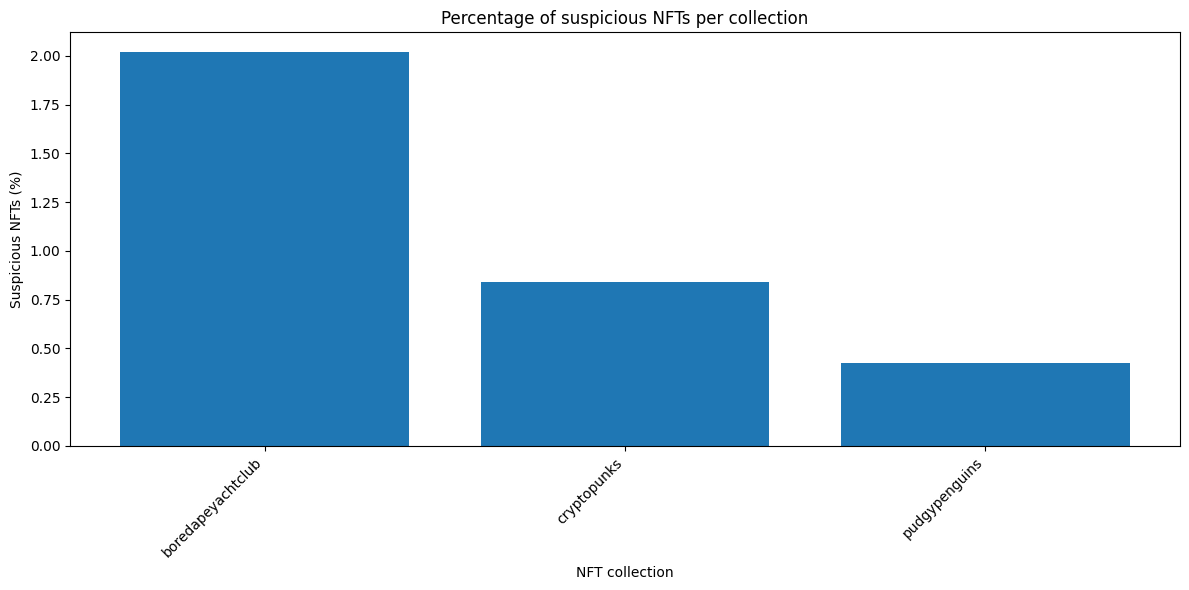

In [35]:

plt.figure(figsize=(12, 6))

plt.bar(
    suspicious_nft_statistics["nft.collection"],
    suspicious_nft_statistics["suspicious_nft_percentage"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Suspicious NFTs (%)")
plt.xlabel("NFT collection")
plt.title("Percentage of suspicious NFTs per collection")

plt.tight_layout()
plt.show()

## Suspicious transaction rate by collection

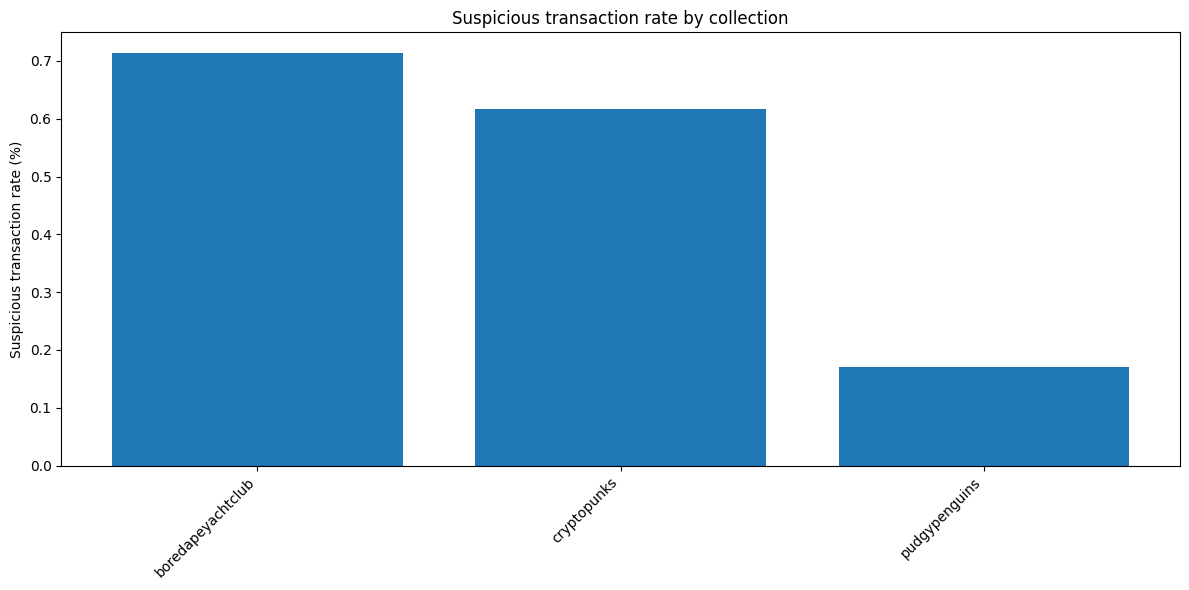

In [7]:
top_collections = (
    suspicious_rate_per_collection
    .sort_values(
        "suspicious_rate",
        ascending=False
    )
)

plt.figure(figsize=(12,6))

plt.bar(
    top_collections["nft.collection"],
    top_collections["suspicious_rate"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Suspicious transaction rate (%)")

plt.title(
    "Suspicious transaction rate by collection"
)

plt.tight_layout()

plt.show()

## Feature prevalence
Frequency of each suspicious indicator - so which rules fire the most often?

In [8]:
feature_summary = pd.DataFrame(
    {
        "Feature": [
            "Self trade",
            "Immediate round trip",
            "Repeated wallet pair",
            "Short holding period",
            "High flip count",
            "Price abnormality",
        ],
        "Count": [
            df["self_trade"].sum(),
            df["immediate_round_trip"].sum(),
            (df["pair_trade_count"] >= 5).sum(),
            (df["holding_seconds"] <= 3600).sum(),
            (df["nft_flip_count"] >= 3).sum(),
            df["price_abnormality"].sum(),
        ]
    }
)

feature_summary

,Feature,Count
0,Self trade,8
1,Immediate round trip,49
2,Repeated wallet pair,76
3,Short holding period,381
4,High flip count,2560
5,Price abnormality,313


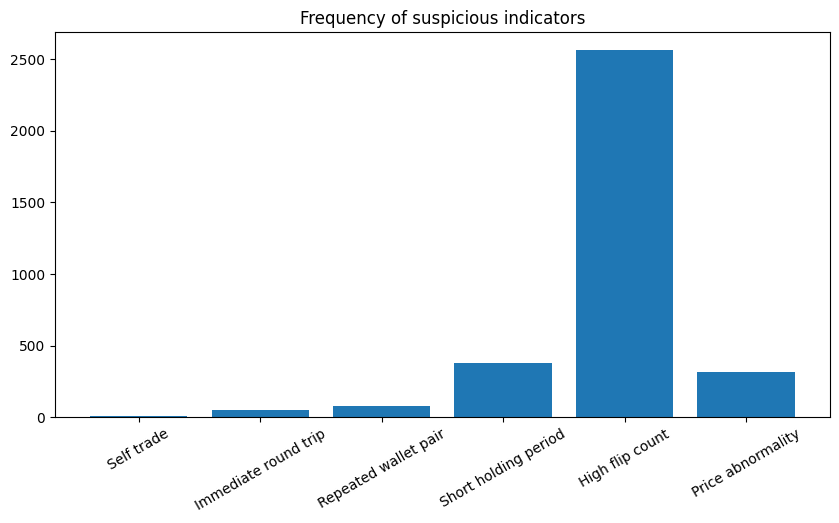

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    feature_summary["Feature"],
    feature_summary["Count"]
)

plt.xticks(rotation=30)

plt.title(
    "Frequency of suspicious indicators"
)

plt.show()

## Wash score distribution

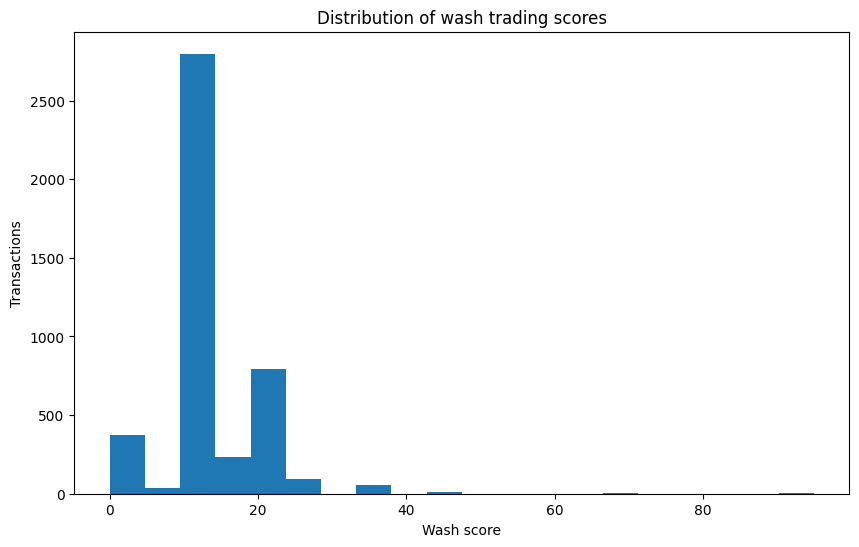

In [10]:
plt.figure(figsize=(10,6))

plt.hist(
    df["wash_score"],
    bins=20
)

plt.xlabel("Wash score")
plt.ylabel("Transactions")

plt.title(
    "Distribution of wash trading scores"
)

plt.show()

## Top suspicious wallets

In [11]:
seller_counts = (
    suspicious_transactions["seller"]
    .value_counts()
)

buyer_counts = (
    suspicious_transactions["buyer"]
    .value_counts()
)

wallet_activity = (
    seller_counts
    .add(buyer_counts, fill_value=0)
    .sort_values(ascending=False)
)

wallet_activity.head(20)

seller
0x54d28b26487e6529cf447434bccf439bea352e5d    12.0
0x1919db36ca2fa2e15f9000fd9cdc2edcf863e685     3.0
0x1ea27bce786a81022dfc156059771e8d3279a9a6     2.0
0x3caebdddfb38d801cf4a2ec638085c36abea9c9e     2.0
0xb751379ff5dbc7ae98279486f151172dd37abaa3     2.0
0x80bf7db69556d9521c03461978b8fc731dbbd4e4     2.0
0x00000f91109c4d0007e90000d9facad5298a0cac     1.0
0xf4c40bf7070fdcf64ecf020bcb583738a6cc3bcd     1.0
0xc67268421283cce9da893ae59767ad8571b558e7     1.0
0xb2d0b117d36cd9a74bafdb3d01ff754b30a66e23     1.0
0x922cc241ee295ec37c048d5e3e2247bc54883998     1.0
0x4ce0f96c459df322df68f393569549d5a54a1929     1.0
0x4f4004cc381ca2a6432a0edcf7c407ebe21be814     1.0
0x0d2eb2be84e68497e2eb8c84b72597450f1b23cc     1.0
0x489d9dfbce0986ed4f21a3398c12bbbbff197a6d     1.0
0x3e6e8b955e6f5484fc95200737e4d092b35c577c     1.0
0x2e206e9728f3cdc06893b4fba95a395942017c5d     1.0
0x0f96a12950561705af0004f3c937c57082e06af7     1.0
0xf76246b0842c92ad5bd745973ca9eb85b937b126     1.0
Name: count, dtype: floa

## Wash wallet statistics

In [12]:
# Count all unique wallets per collection (either as a seller or as a buyer)

all_wallet_stats = []

for collection, group in df.groupby("nft.collection"):

    all_wallets = pd.concat([
        group["seller"],
        group["buyer"]
    ]).dropna().unique()

    all_wallet_stats.append({
        "nft.collection": collection,
        "all_wallets": len(all_wallets)
    })

all_wallet_stats = pd.DataFrame(all_wallet_stats)

display(all_wallet_stats)

,nft.collection,all_wallets
0,boredapeyachtclub,841
1,cryptopunks,509
2,pudgypenguins,1188


In [14]:
# Count suspicious wallets per collection.
# A suspicious wallet is any wallet that appears in suspicious_transactions
# as seller or buyer.

suspicious_wallet_stats = []

for collection, group in suspicious_transactions.groupby("nft.collection"):

    suspicious_wallets = pd.concat([
        group["seller"],
        group["buyer"]
    ]).dropna().unique()

    suspicious_wallet_stats.append({
        "nft.collection": collection,
        "suspicious_wallets": len(suspicious_wallets)
    })

suspicious_wallet_stats = pd.DataFrame(suspicious_wallet_stats)

display(suspicious_wallet_stats)

,nft.collection,suspicious_wallets
0,boredapeyachtclub,12
1,cryptopunks,5
2,pudgypenguins,4


In [15]:
# Merge total wallet counts with suspicious wallet counts.
wash_wallet_statistics = (
    all_wallet_stats
    .merge(
        suspicious_wallet_stats,
        on="nft.collection",
        how="left"
    )
)

wash_wallet_statistics["suspicious_wallets"] = (
    wash_wallet_statistics["suspicious_wallets"]
    .fillna(0)
    .astype(int)
)

# Calculate percentage of suspicious wallets per collection.
wash_wallet_statistics["suspicious_wallet_percentage"] = (
    wash_wallet_statistics["suspicious_wallets"]
    / wash_wallet_statistics["all_wallets"]
    * 100
)

# Sort by percentage, from highest to lowest.
wash_wallet_statistics = (
    wash_wallet_statistics
    .sort_values(
        "suspicious_wallet_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(wash_wallet_statistics)

,nft.collection,all_wallets,suspicious_wallets,suspicious_wallet_percentage
0,boredapeyachtclub,841,12,1.426873
1,cryptopunks,509,5,0.982318
2,pudgypenguins,1188,4,0.336700


In [16]:
# Add a summary row with overall statistics.
total_all_wallets = pd.concat([
    df["seller"],
    df["buyer"]
]).dropna().nunique()

total_suspicious_wallets = pd.concat([
    suspicious_transactions["seller"],
    suspicious_transactions["buyer"]
]).dropna().nunique()

overall_percentage = (
    total_suspicious_wallets
    / total_all_wallets
    * 100
)

overall_wallet_summary = pd.DataFrame({
    "nft.collection": ["Overall"],
    "all_wallets": [total_all_wallets],
    "suspicious_wallets": [total_suspicious_wallets],
    "suspicious_wallet_percentage": [overall_percentage]
})

display(overall_wallet_summary)

,nft.collection,all_wallets,suspicious_wallets,suspicious_wallet_percentage
0,Overall,2266,19,0.838482


In [17]:
wash_wallet_statistics_with_total = pd.concat(
    [
        wash_wallet_statistics,
        overall_wallet_summary
    ],
    ignore_index=True
)

display(wash_wallet_statistics_with_total)

,nft.collection,all_wallets,suspicious_wallets,suspicious_wallet_percentage
0,boredapeyachtclub,841,12,1.426873
1,cryptopunks,509,5,0.982318
2,pudgypenguins,1188,4,0.336700
3,Overall,2266,19,0.838482


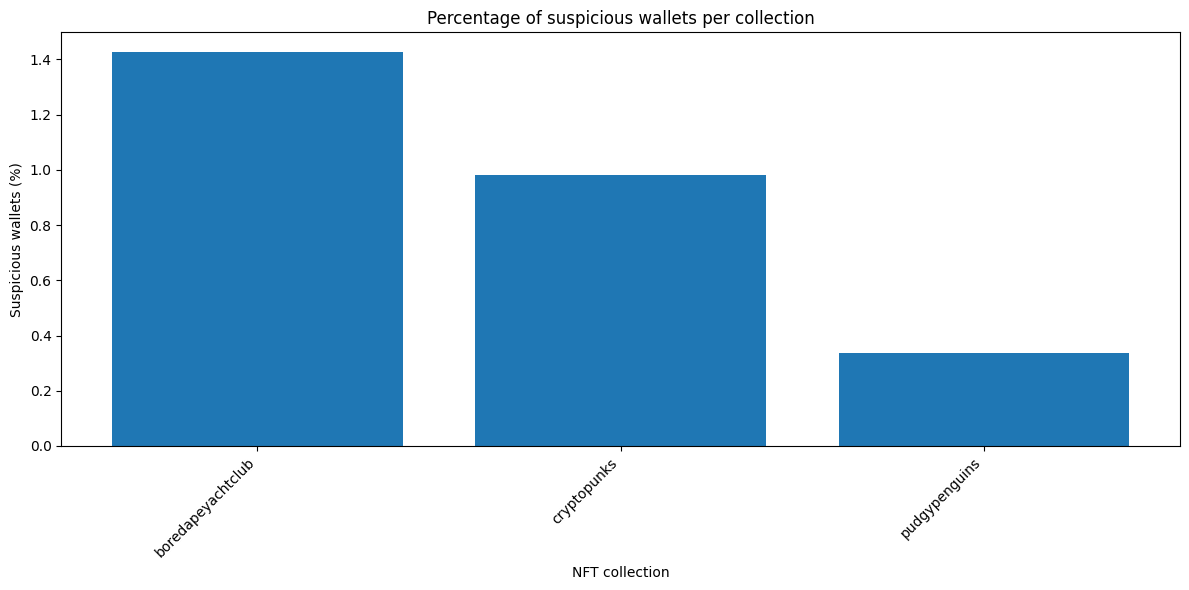

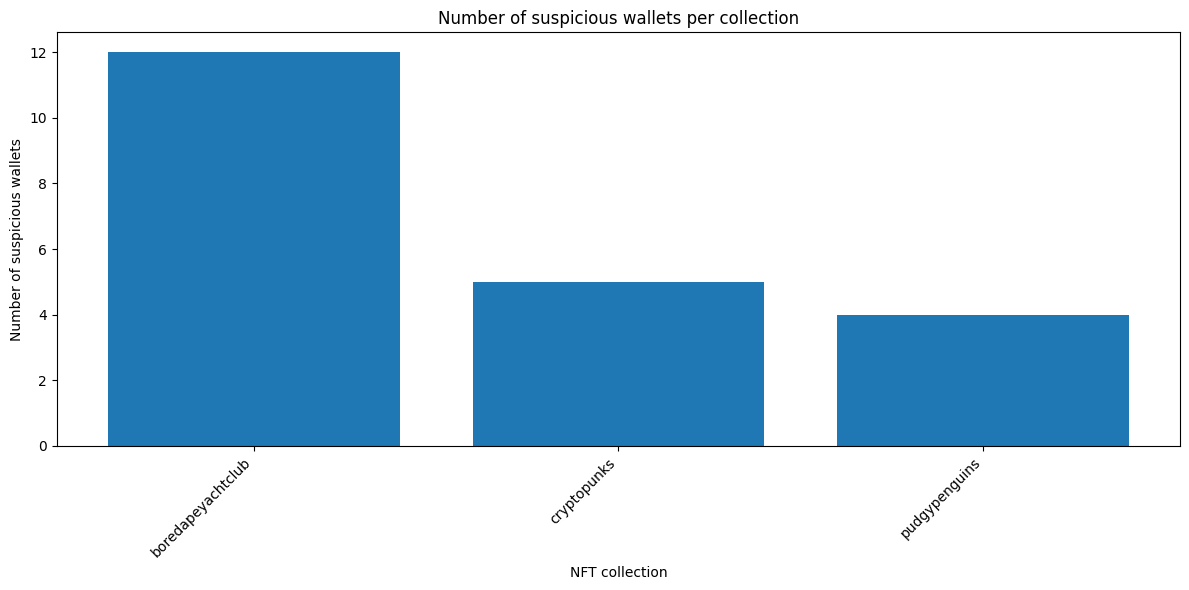

In [18]:
# Plot data
plot_data = wash_wallet_statistics.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["nft.collection"],
    plot_data["suspicious_wallet_percentage"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Suspicious wallets (%)")
plt.xlabel("NFT collection")

plt.title(
    "Percentage of suspicious wallets per collection"
)

plt.tight_layout()

plt.show()


# Plot absolute number of suspicious wallets by collection.
plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["nft.collection"],
    plot_data["suspicious_wallets"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Number of suspicious wallets")
plt.xlabel("NFT collection")

plt.title(
    "Number of suspicious wallets per collection"
)

plt.tight_layout()

plt.show()

## Repeated wallet pairs
This section identifies wallet pairs that trade with each other unusually often.

In [19]:
# Count transactions between every seller-buyer pair.
wallet_pairs = (
    df
    .groupby(["seller", "buyer"])
    .size()
    .reset_index(name="transaction_count")
    .sort_values(
        "transaction_count",
        ascending=False
    )
    .reset_index(drop=True)
)

# Basic statistics
display(wallet_pairs.head(20))
print("Number of unique wallet pairs:", len(wallet_pairs))
print(
    "Maximum transactions between a single pair:",
    wallet_pairs["transaction_count"].max()
)

print(
    "Average transactions per pair:",
    round(
        wallet_pairs["transaction_count"].mean(),
        2
    )
)

,seller,buyer,transaction_count
0,0xff53e1da7b67ae676d7742f858aab5bd4bc937f6,0x5b468edb7688e9ae6c1fa5a6d2debbef06e92907,14
1,0x0232d1083e970f0c78f56202b9a666b526fa379f,0x8be240e8689547f1068a835d14f1d943958095dc,13
2,0xd8f24f5f0382e197c1e87ad82b357209383470cf,0xede4e6d73a5277910a6d5459d255e4d2095a2373,9
3,0xa25803ab86a327786bb59395fc0164d826b98298,0x1919db36ca2fa2e15f9000fd9cdc2edcf863e685,7
4,0x54d28b26487e6529cf447434bccf439bea352e5d,0x54d28b26487e6529cf447434bccf439bea352e5d,6
5,0x1ea27bce786a81022dfc156059771e8d3279a9a6,0x4ba850fada1188eea36c645d4ca32b3e85b88ae8,6
6,0xf76246b0842c92ad5bd745973ca9eb85b937b126,0x195f46025a6926968a1b3275822096eb12d97e70,6
7,0xd43dfa9024096b0224adf6859e22fbc35ea2b21f,0x3bb4fa84b120ac0dbb4a6bb0442fe2c47e324a93,5
8,0xcf8d60fb330a556406fe95e6fb0cb955dae9e2d7,0x531fb8dc4e65b5bc64def5d4915082ed8fdd8a8c,5
9,0x3bb4fa84b120ac0dbb4a6bb0442fe2c47e324a93,0x8a7d2a5fa5912e6feef47c8184d4e4ff56681f0c,5


Number of unique wallet pairs: 4015
Maximum transactions between a single pair: 14
Average transactions per pair: 1.1
